## 1. Load and Inspect the Data
To understand the structure of the dataset; how many samples, how many genes, and what the target variable looks like.

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("/kaggle/input/datasets/brunogrisci/brain-cancer-gene-expression-cumida/Brain_GSE50161.csv")

print("Shape:", df.shape)
df.head()

Shape: (130, 54677)


,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,834,ependymoma,12.498150,7.604868,6.880934,9.027128,4.176175,7.224920,6.085942,6.835999,...,9.979005,9.926470,12.719785,12.777792,5.403657,4.870548,4.047380,3.721936,4.516434,4.749940
1,835,ependymoma,13.067436,7.998090,7.209076,9.723322,4.826126,7.539381,6.250962,8.012549,...,11.924749,11.215930,13.605662,13.401342,5.224555,4.895315,3.786437,3.564481,4.430891,4.491416
2,836,ependymoma,13.068179,8.573674,8.647684,9.613002,4.396581,7.813101,6.007746,7.178156,...,12.154405,11.532460,13.764593,13.477800,5.303565,5.052184,4.005343,3.595382,4.563494,4.668827
3,837,ependymoma,12.456040,9.098977,6.628784,8.517677,4.154847,8.361843,6.596064,6.347285,...,11.969072,11.288801,13.600828,13.379029,4.953429,4.708371,3.892318,3.759429,4.748381,4.521275
4,838,ependymoma,12.699958,8.800721,11.556188,9.166309,4.165891,7.923826,6.212754,6.866387,...,11.411701,11.169317,13.751442,13.803646,4.892677,4.773806,3.796856,3.577544,4.504385,4.541450


## 2. Check Data Types and Missing Values


In [12]:
df.info()
print("\nTotal missing values:", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Columns: 54677 entries, samples to AFFX-TrpnX-M_at
dtypes: float64(54675), int64(1), object(1)
memory usage: 54.2+ MB

Total missing values: 0


## 3. Explore the Target Variable
`type` is what we're predicting. Checking its distribution up front matters here because 
the classes are imbalanced and this will affect which evaluation metric we trust later.

In [13]:
df['type'].value_counts()

type
ependymoma               46
glioblastoma             34
medulloblastoma          22
pilocytic_astrocytoma    15
normal                   13
Name: count, dtype: int64

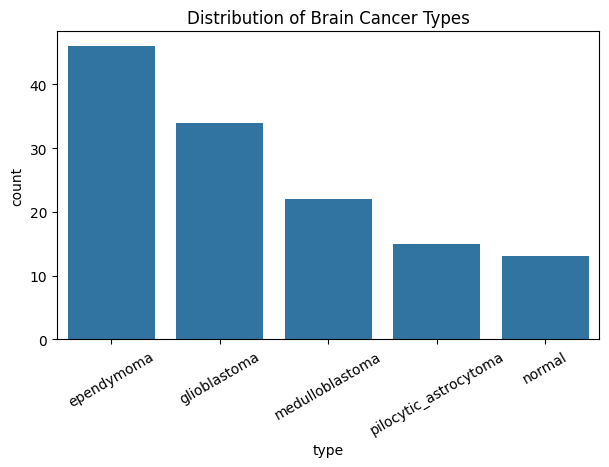

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))
sns.countplot(data=df, x='type', order=df['type'].value_counts().index)
plt.title("Distribution of Brain Cancer Types")
plt.xticks(rotation=30)
plt.show()

## 4. Drop Non-Feature Columns
`samples` is just a row ID and it carries no biological signal, so it must be dropped 
before training or it'll be treated as a (meaningless) feature.

In [15]:
X = df.drop(columns=['samples', 'type'])
y = df['type']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (130, 54675)
Target shape: (130,)


## 5. Encode the Target Labels

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Sanity check: confirm the mapping
dict(zip(le.classes_, range(len(le.classes_))))

{'ependymoma': 0,
 'glioblastoma': 1,
 'medulloblastoma': 2,
 'normal': 3,
 'pilocytic_astrocytoma': 4}

## 6. Train/Test Split (Stratified)
With only 130 samples spread across 5 classes, a plain random split risks leaving 
a minority class with almost no test samples. `stratify=y_encoded` keeps class 
proportions consistent across the split.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (104, 54675)
Test shape: (26, 54675)


## 7. Feature Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  

## 8. Dimensionality Reduction with PCA
This is the core challenge of this dataset: 54,675 genes but only 130 samples 
(a "high-dimensional, low-sample-size" problem). Training directly on all genes 
would overfit badly. PCA compresses correlated genes into a much smaller set of 
components while retaining 95% of the variance in the data.

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original features: {X_train_scaled.shape[1]}")
print(f"Components after PCA: {pca.n_components_}")

Original features: 54675
Components after PCA: 77


## 9. Train a Random Forest Classifier


In [21]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=300, random_state=42)
clf.fit(X_train_pca, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

## 10. Cross-Validate


In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(clf, X_train_pca, y_train, cv=5)
print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV Accuracy: 0.856 ± 0.073


## 11. Evaluate on the Test Set


In [23]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test_pca)
print(classification_report(y_test, y_pred, target_names=le.classes_))

                       precision    recall  f1-score   support

           ependymoma       0.73      0.89      0.80         9
         glioblastoma       1.00      0.86      0.92         7
      medulloblastoma       1.00      0.50      0.67         4
               normal       1.00      1.00      1.00         3
pilocytic_astrocytoma       0.75      1.00      0.86         3

             accuracy                           0.85        26
            macro avg       0.90      0.85      0.85        26
         weighted avg       0.88      0.85      0.84        26



## 12. Confusion Matrix
Visualising exactly which classes get confused with each other 

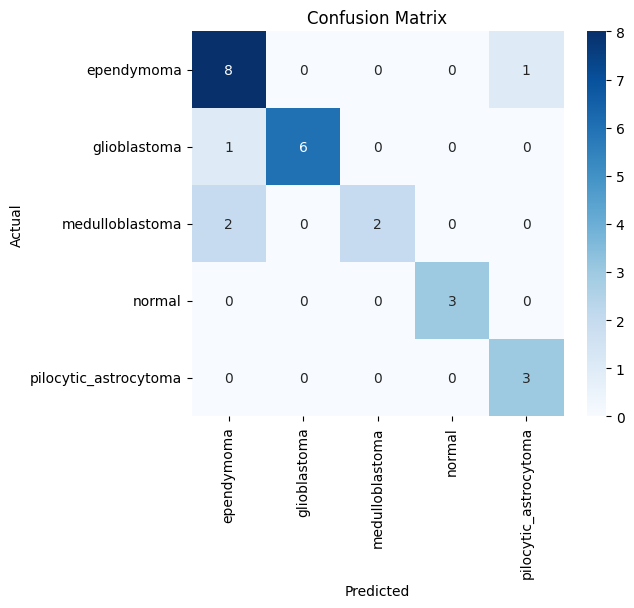

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 13. Explainability with SHAP
PCA components aren't interpretable on their own ("PC7" means nothing biologically). 
To find out *which actual genes* drive predictions, we train a second Random Forest 
directly on the top variance genes (no PCA) and apply SHAP to explain its decisions.

In [25]:
# Select top 500 most variable genes (skips PCA so genes stay identifiable)
top_genes = X_train.var().sort_values(ascending=False).head(500).index

X_train_top = X_train[top_genes]
X_test_top = X_test[top_genes]

clf_interp = RandomForestClassifier(n_estimators=300, random_state=42)
clf_interp.fit(X_train_top, y_train)

print("Interpretable model accuracy:", clf_interp.score(X_test_top, y_test))

Interpretable model accuracy: 0.9615384615384616


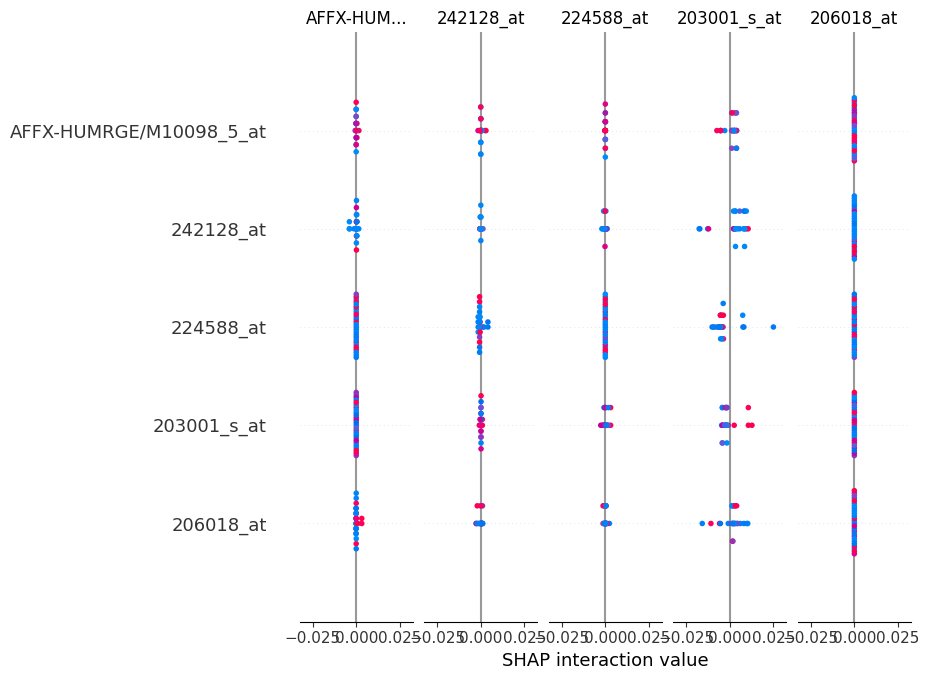

In [26]:
import shap

explainer = shap.TreeExplainer(clf_interp)
shap_values = explainer.shap_values(X_test_top)

shap.summary_plot(shap_values, X_test_top, class_names=le.classes_)

## 14. Identify Top Genes
Pulling out the specific gene names driving predictions and look up their 
known biological function 

In [28]:
# Mean absolute SHAP value for each gene, averaged across samples and classes

shap_array = np.array(shap_values)

print("SHAP shape:", shap_array.shape)
print("Number of genes:", len(top_genes))

# Average across samples and classes, keeping the gene dimension
mean_shap = np.abs(shap_array).mean(axis=(0, 2))

top_shap_genes = pd.Series(
    mean_shap,
    index=top_genes
).sort_values(ascending=False).head(10)

top_shap_genes

SHAP shape: (26, 500, 5)
Number of genes: 500


220156_at       0.009613
205932_s_at     0.008781
1562371_s_at    0.007349
1553734_at      0.006052
242162_at       0.005640
229170_s_at     0.005265
231077_at       0.004865
204465_s_at     0.004847
220591_s_at     0.004810
239916_at       0.004377
dtype: float64